[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EnsaeStatApp/CorrelationEquityBond/blob/main/RegimeDetector/HMM_Macro_Regime_Analysis.ipynb)

# **Corrélation indices actions-obligations : Détection de régimes macroéconomiques et caractérisation financière sur la période 1970-2025**

Ce code est de la description pure (full in-sample). Il initialise un HMM et le fit sur un ensemble de variables macroéconomiques sélectionnées (production industrielle, inflation, utilisation des capacités, chômage, sentiment des consommateurs, taux courts et heures travaillées) de 1970 à 2025, afin d'identifier 4 régimes macroéconomiques distincts. Les régimes sont ensuite caractérisés sur les données financières (S&P500, T-Bond 10y, AAA, BAA) via un objet de type RegimeStatisticalAnalyzer, qui affiche les moyennes, volatilités et corrélations entre actifs conditionnellement à chaque régime. Par ailleurs, des tests statistiques entre régimes sont appliqués (Levene pour les volatilités et Fisher-z pour les corrélations), complétés par des intervalles de confiance bootstrap à 95%.

L'approche se distingue d'un HMM financier classique sur deux points :
- Le **signal de détection** est macroéconomique — le modèle apprend les régimes depuis les dynamiques réelles de l'économie, pas depuis les prix des actifs
- La **caractérisation financière** est réalisée a posteriori — les statistiques de rendement et corrélation sont calculées conditionnellement aux régimes détectés sur le macro, ce qui permet d'interpréter leur signification pour un investisseur





# Connection au github

In [2]:
import os
import sys
import shutil

if 'google.colab' in str(get_ipython()):
    repo_url = 'https://github.com/EnsaeStatApp/CorrelationEquityBond.git'
    repo_name = 'CorrelationEquityBond'

    # 1. Suppression du repo existant
    if os.path.exists(f'/content/{repo_name}'):
        shutil.rmtree(f'/content/{repo_name}')
        print(f"🗑️ Ancien repo supprimé")

    # 2. Purge du cache Python
    for mod in list(sys.modules.keys()):
        if 'RegimeDetector' in mod:
            del sys.modules[mod]

    # 3. Clone propre
    os.chdir('/content')
    !git clone {repo_url}

    # 4. Déplacement + ajout au path
    os.chdir(f'/content/{repo_name}')
    if os.getcwd() not in sys.path:
        sys.path.insert(0, os.getcwd())

    print(f"✅ Répertoire actuel : {os.getcwd()}")

Cloning into 'CorrelationEquityBond'...
remote: Enumerating objects: 780, done.
remote: Counting objects: 100% (249/249), done.
remote: Compressing objects: 100% (176/176), done.
remote: Total 780 (delta 182), reused 73 (delta 73), pack-reused 531 (from 1)
Receiving objects: 100% (780/780), 20.52 MiB | 33.61 MiB/s, done.
Resolving deltas: 100% (382/382), done.
✅ Répertoire actuel : /content/CorrelationEquityBond


# Installation de la librairie ssm via le repo git

In [3]:
!pip install git+https://github.com/lindermanlab/ssm.git

  Cloning https://github.com/lindermanlab/ssm.git to /tmp/pip-req-build-l373k6yq
  Running command git clone --filter=blob:none --quiet https://github.com/lindermanlab/ssm.git /tmp/pip-req-build-l373k6yq
  Resolved https://github.com/lindermanlab/ssm.git to commit eb6c8aa33e5311d3564075807dec340759dd8081
  Preparing metadata (setup.py) ... done
  Created wheel for ssm: filename=ssm-0.0.1-cp312-cp312-linux_x86_64.whl size=614355 sha256=58d61eb7765577fbddfe6abc0916b98562a2b23c4aa6586e7c283b8aa8efa363
  Stored in directory: /tmp/pip-ephem-wheel-cache-4w9nztin/wheels/a8/a9/68/b62b9b4d4ee3afda66bd9eec0cb2fbc9a79a7504e9d6d17397
Successfully built ssm


# Préparation des données

In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("monthly_data/dataset_with_macros.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date").sort_index()
df.drop(columns="Unnamed: 0", inplace=True)

In [5]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Colonnes log returns financiers (déjà calculées dans le dataset)
ASSET_LOG_RET_VARS = ["Stock_Log_Return", "Bond_Log_Return", "AAA_Log_Return", "BAA_Log_Return"]
asset_names = ["S&P500", "T-bond 10y", "Aaa", "Baa"]

# --- Reste inchangé ---
MACRO_SELECTED = ["INDPRO", "PPIACO", "TCU", "UNRATE", "UMCSENT", "TB3MS","CPI"]
MACRO_DIFF  = ["INDPRO", "PPIACO", "TCU", "UNRATE","CPI"]
MACRO_LEVEL = ["UMCSENT", "TB3MS"]

all_cols = ASSET_LOG_RET_VARS + MACRO_SELECTED
df_model = df[all_cols].dropna().copy()

df_model_aligned = df_model.copy()
for col in MACRO_DIFF:
    if col in df_model_aligned.columns:
        df_model_aligned[col] = df_model_aligned[col].pct_change(12)

df_model_aligned = df_model_aligned.dropna()

dates = df_model_aligned.index
train_mask = (dates <= pd.Timestamp("2025-01-01")) & (dates >= pd.Timestamp("1970-01-01"))
dates_train = dates[train_mask]

# Log returns financiers pour les analyses (checker, reporter)
Y_train_raw = df_model_aligned[ASSET_LOG_RET_VARS].values[train_mask].astype(float)

# Observations macro pour le fit HMM — inchangé
X_train_raw = df_model_aligned[MACRO_SELECTED].values[train_mask].astype(float)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
data_to_fit = [X_train_scaled]

T, D_macro = X_train_scaled.shape
SEED = 120
np.random.seed(SEED)

print(f"Train : {dates_train[0].date()} → {dates_train[-1].date()} ({T} mois)")
print(f"Y_train_raw shape    : {Y_train_raw.shape}")
print(f"X_train_scaled shape : {X_train_scaled.shape}")
print(f"Variables en variation trimestrielle : {MACRO_DIFF}")
print(f"Variables en niveau                  : {MACRO_LEVEL}")

Train : 1970-02-01 → 2025-01-01 (597 mois)
Y_train_raw shape    : (597, 4)
X_train_scaled shape : (597, 7)
Variables en variation trimestrielle : ['INDPRO', 'PPIACO', 'TCU', 'UNRATE', 'CPI']
Variables en niveau                  : ['UMCSENT', 'TB3MS']


# Initialisation et fit du HMM descriptif

In [6]:
from RegimeDetector.HMM_detector import HMMDetector
from RegimeDetector.HMMCoherenceChecker import HMMCoherenceChecker

detector = HMMDetector(
    n_states=3,
    random_state=42,
    kappa=10.0,
    n_restarts=10,
    n_iter=200
)

# fit sur les macro, avec les log returns financiers stockés pour les métriques
detector.fit(observations=data_to_fit, log_returns=Y_train_raw)
states = detector.viterbi_states

# Le checker reçoit les log returns financiers, pas les macro
checker = HMMCoherenceChecker(
    detector=detector,
    log_returns=Y_train_raw,   # ← données financières
    asset_names=asset_names,
    min_duration=3.0,
    min_freq=0.03,
    sig_threshold=0.45,
    sig_max_cond_number=1e12
)

checker.report_emission_stats()
for ref_idx in range(detector.K):
    checker.report_transition_stats(ref_idx=ref_idx)
checker.final_verdict()


DIAGNOSTIC COMPLET DES ÉMISSIONS (BOOTSTRAP & TESTS)

1. VOLATILITÉS ANNUELLES AVEC INTERVALLES DE CONFIANCE :


Value  Lower_Bound  Upper_Bound
Regime Label                                       
0      S&P500      0.1807       0.1340       0.2253
       T-bond 10y  0.0760       0.0605       0.0913
       Aaa         0.1761       0.1342       0.2151
       Baa         0.1520       0.1121       0.1904
1      S&P500      0.1001       0.0883       0.1119
       T-bond 10y  0.0607       0.0559       0.0651
       Aaa         0.1012       0.0918       0.1111
       Baa         0.0873       0.0788       0.0962
2      S&P500      0.1405       0.1208       0.1588
       T-bond 10y  0.0944       0.0766       0.1113
       Aaa         0.1365       0.1149       0.1551
       Baa         0.1128       0.0937       0.1295


2. CORRÉLATIONS AVEC INTERVALLES DE CONFIANCE :


Value  Lower_Bound  Upper_Bound
Regime Label                                                
0      S&P500 / T-bond 10y -0.3457      -0.5510      -0.1343
       S&P500 / Aaa        -0.1642      -0.3798       0.0877
       S&P500 / Baa        -0.4933      -0.7152      -0.1291
       T-bond 10y / Aaa    -0.6344      -0.8069      -0.4039
       T-bond 10y / Baa    -0.3343      -0.6317      -0.0123
       Aaa / Baa            0.7351       0.6379       0.8322
1      S&P500 / T-bond 10y  0.0717      -0.0571       0.2028
       S&P500 / Aaa        -0.1342      -0.2417      -0.0253
       S&P500 / Baa        -0.2050      -0.3051      -0.1002
       T-bond 10y / Aaa    -0.8178      -0.8562      -0.7709
       T-bond 10y / Baa    -0.7683      -0.8193      -0.7088
       Aaa / Baa            0.9256       0.9036       0.9429
2      S&P500 / T-bond 10y  0.3409       0.1824       0.4896
       S&P500 / Aaa        -0.4446      -0.5698      -0.3092
       S&P500 / Baa        -0.4820      -0.6054      -0.3478
       T-bond 10y / Aaa    -0.8547      -0.9002      -0.8049
       T-bond 10y / Baa    -0.7403      -0.8084      -0.6648
       Aaa / Baa            0.9227       0.8803       0.9521


3. TESTS DE SÉPARABILITÉ (TOUTES LES PAIRES) :
- Significativité des Volatilités (Levene) :


...

,Type,Transition,Variable,Coef,Std_Err,P_Value,Significatif
0,Intercept,R0 -> R0,Base_Prob,4.6901,1.0049,0.0000,True
1,Intercept,R0 -> R1,Base_Prob,0.6880,1.2279,0.5753,False
2,Intercept,R1 -> R0,Base_Prob,1.0992,1.1547,0.3412,False
3,Intercept,R1 -> R1,Base_Prob,5.9124,1.0013,0.0000,True
4,Intercept,R2 -> R0,Base_Prob,-36.8124,0.0000,0.0000,True
5,Intercept,R2 -> R1,Base_Prob,-3.8187,0.5837,0.0000,True



2. DYNAMIQUE MOYENNE ET PERSISTANCE :


,Durée_Moyenne (mois),Prob_Stationnaire,Prob_Rester
0,37.4142,0.1939,0.9733
1,93.3568,0.6450,0.9893
2,46.5447,0.1611,0.9785



RAPPORT DE COHÉRENCE HMM : 78.11%
1. SÉPARABILITÉ : 50.0% (Seuil: 45%) -> OK
2. STABILITÉ    : VALIDE
3. PERSISTANCE  : 37.4 mois (min 3.0) -> OK
4. CONFIANCE    : 98.4% (Entropie) -> SOLIDE
--------------------------------------------------
DYNAMIQUE DES RÉGIMES :
    Durée   Fréq
0  37.414  0.194
1  93.357  0.645
2  46.545  0.161

VERDICT : MODÈLE VALIDÉ (Robuste)


np.float64(0.7811026853336016)

### Interprétation des résultats

**Émissions — Volatilités et corrélations conditionnelles**

Les trois régimes se hiérarchisent clairement. **R1** est le régime normal dominant (S&P500 ≈ 10 %, T-bond ≈ 6 %, IC bootstrap très resserrés). **R0** concentre le stress crédit : vol actions quasi doublée (18 %) et vol crédit (Aaa 17.6 %, Baa 15.2 %) supérieure à la vol T-bond — signature d'un régime dominé par le risque de défaut. **R2** capte les tensions taux, identifié par la vol T-bond la plus élevée (9.4 %) alors que la vol actions reste intermédiaire. Le discriminant principal est la corrélation **S&P500 / T-bond 10y** : **−0.35 en R0** (*flight-to-quality*), **+0.07 en R1** (découplage normal), **+0.34 en R2** (co-mouvement baissier inflationniste). La corrélation Aaa/Baa reste élevée et stable entre R1 et R2 (0.93 vs 0.92) mais chute à 0.74 en R0 — dispersion attendue des spreads en période de stress.

**Séparabilité statistique**

15 tests sur 30 significatifs après Bonferroni (**50 %, seuil 45 % → validé**). Les paires R0↔R1 et R1↔R2 sont séparables sur la volatilité (Levene, p-ajustées < 0.001), mais **R0 vs R2 ne l'est sur aucun actif** : leur distinction repose entièrement sur la *structure* de corrélation (Fisher-Z sur S&P/T-bond et T-bond/Baa), pas sur le niveau de variance. Ce résultat justifie le choix d'un modèle multivarié plutôt qu'un switching univarié sur la vol du S&P.

**Transitions et dynamique des régimes**

Les termes diagonaux (R0→R0, R1→R1, R2→R2) sont tous significatifs à p < 0.001 : la persistance des trois régimes est identifiée sans ambiguïté, et l'axe R0 ↔ R1 (stress ↔ calme) porte la circulation principale. **Point structurel à signaler :** la transition **R2 → R0** apparaît numériquement interdite (coef ≈ −37 en logit, Std_Err = 0) ; le modèle impose donc le passage par R1 pour aller d'un régime taux/inflation à un régime de stress crédit, ce qui limite la représentation des basculements rapides (type 2022). Les Std_Err élevés sur certaines lignes R2 (réf. R0) reflètent la faible fréquence de sortie de R2, pas une instabilité du fit. Les durées moyennes et fréquences long-terme sont cohérentes avec une lecture macro-cyclique :

| Régime | Durée moyenne | Fréquence long-terme | Interprétation |
|--------|---------------|----------------------|----------------|
| R0 | ~37 mois | 19 % | Stress / crédit |
| R1 | ~93 mois | 65 % | Régime normal dominant |
| R2 | ~47 mois | 16 % | Tension taux / inflation |



**Verdict global**

**Score de cohérence : 78.1 % — modèle validé sur les quatre critères** (séparabilité 50 %, stabilité numérique OK, persistance min 37 mois, confiance Viterbi 98.4 %). L'interprétation économique des trois états est lisible et non-redondante, la distinction R0/R2 reposant sur la structure de corrélation. La principale réserve est la transition R2→R0 contrainte à zéro, à mentionner comme limite lors de la discussion des scénarios de stress post-inflation.

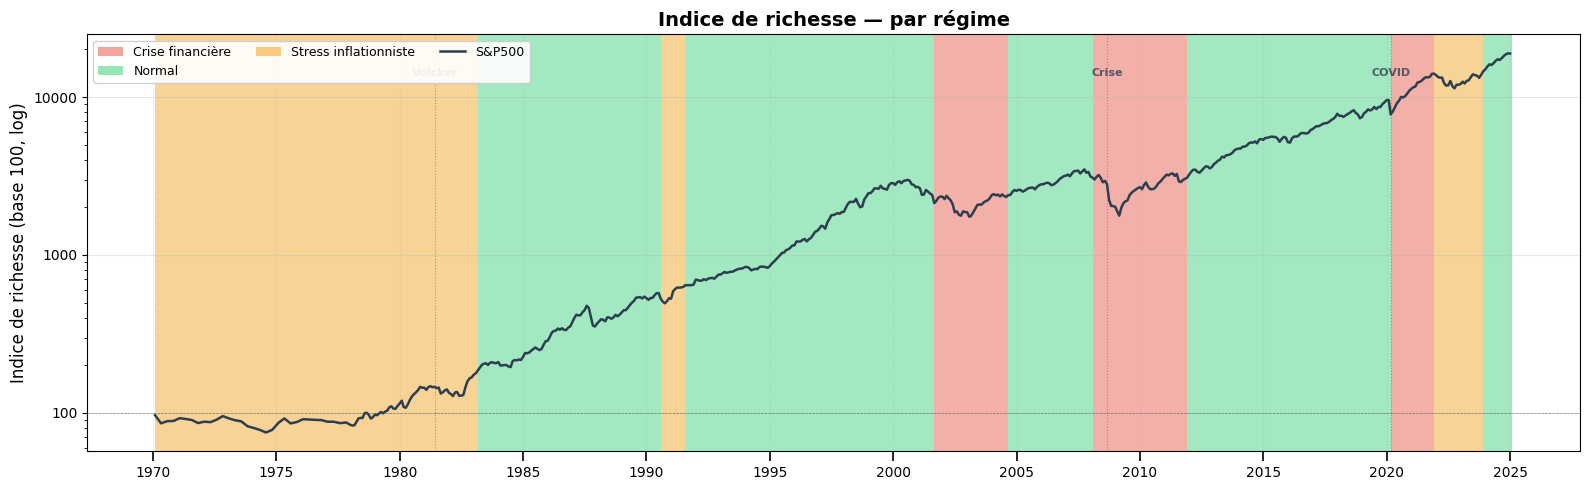

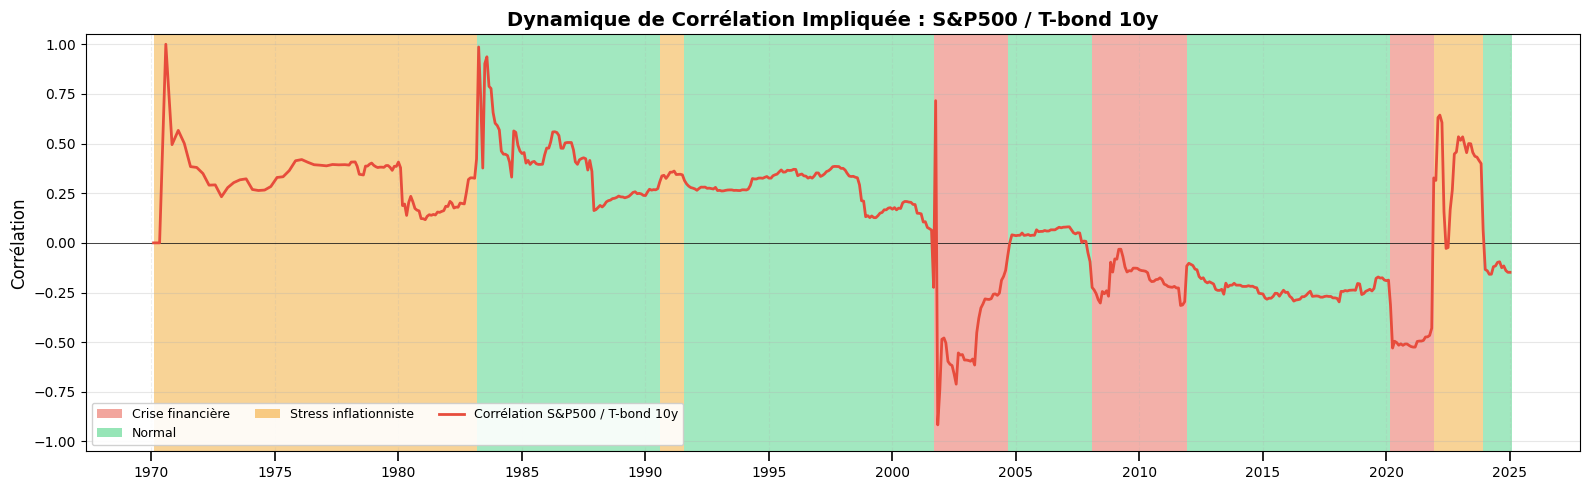

In [9]:
from RegimeDetector.RegimeReporter import RegimeReporter

regime_labels = {
    0: "Crise financière",        # R0 : flight-to-quality, vol crédit ↑↑, corr S&P/T-bond < 0
    1: "Normal",                   # R1 : régime dominant (65 % du temps)
    2: "Stress inflationniste"    # R2 : vol T-bond ↑, corr S&P/T-bond > 0
}

regime_couleurs = {
    0: "#e74c3c",   # rouge  — crise
    1: "#2ecc71",   # vert   — normal
    2: "#f39c12"    # violet — inflation / taux
}

mes_crises = {"Volcker": "1981-06-01", "Crise": "2008-09-01", "COVID": "2020-03-01"}

visualizer = RegimeReporter(
    detector=detector,
    log_returns=Y_train_raw,   # ← données financières, pas les macro
    dates=dates_train,
    states=states,
    asset_names=asset_names,   # ["S&P500", "T-bond 10y", "Aaa", "Baa"]
    regime_labels=regime_labels,
    regime_colors=list(regime_couleurs.values()),
    events_dict=mes_crises
)

fig1 = visualizer.plot_wealth_index()
fig2 = visualizer.plot_implied_correlation(asset_i=0, asset_j=1)


ATTENTION : la légende correspond à un ancien fit et les régimes pourraient changer une fois la stabilité établie

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful